<a href="https://colab.research.google.com/github/inefable12/mecanismos/blob/main/Mecanismo_TransferenciaProton_XTB_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$\Large \textit{Colegio Químico del Perú | Región Cusco}$$
$$\large \textbf{Sesión 6 - Cuaderno 2 | Perfil de Energía}$$

_Dr. Jesus Alvarado Huayhuaz_

# 1. Introducción

1. Relaxed Surface Scan

En español, **Escaneo relajado de la superficie de energía potencial** (también se dice barrido relajado de la superficie de energía potencial).

*Idea básica:*

Se explora la superficie de energía potencial (PES) variando gradualmente una coordenada geométrica (por ejemplo, una distancia de enlace, ángulo o dihedro) mientras el resto de la estructura se optimiza.

*Procedimiento:*

Se fija una coordenada estructural (por ejemplo, la distancia entre dos átomos).

Esa coordenada se cambia paso a paso.

En cada paso se optimizan todas las demás coordenadas.

Se obtiene un perfil de energía.

*Resultado:*

El punto de máxima energía en el perfil suele estar cerca del estado de transición.

*Uso típico:*

Reacciones simples donde se sabe qué enlace se rompe o se forma.

2. Nudged Elastic Band (NEB)

En español, **Método de la banda elástica nudged** (o más formalmente método de la banda elástica corregida).

*Idea básica:*

Este método encuentra el camino de mínima energía (MEP, Minimum Energy Path) entre reactivos y productos.

*Procedimiento:*

Se define la estructura inicial (reactivos) y la final (productos).

Se generan varias estructuras intermedias llamadas imágenes.

Estas imágenes se conectan mediante resortes ficticios (elastic band).

*Durante la optimización:*

las imágenes se ajustan para seguir el camino de menor energía,

los resortes mantienen una separación uniforme entre ellas.

*Resultado:*

La imagen con mayor energía corresponde aproximadamente al estado de transición.

*Uso típico:*

- Reacciones complejas

- Procesos en superficies catalíticas o sólidos

- Cuando no se conoce la coordenada de reacción

| Método               | Traducción                                             | Idea principal                                                    |
| -------------------- | ------------------------------------------------------ | ----------------------------------------------------------------- |
| Relaxed Surface Scan | Escaneo relajado de la superficie de energía potencial | Se modifica una coordenada y se optimiza el resto                 |
| NEB                  | Método de la banda elástica nudged                     | Encuentra el camino de mínima energía entre reactivos y productos |


# 2. Requerimientos

In [ ]:
!pip install condacolab

In [ ]:
import condacolab
condacolab.install()

In [ ]:
!conda install conda-forge::xtb

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 3. Ejemplo: Aspirina vs serina

**Reactantes**

aspirina sin H (anión):

CC(=O)OC1=CC=CC=C1C(=O)[O-]

serinaH:

OCC(N)C(=O)O

**Productos**

aspirinaH:

CC(=O)OC1=CC=CC=C1C(=O)O

serina sin H (anión):

[O-]CC(N)C(=O)O

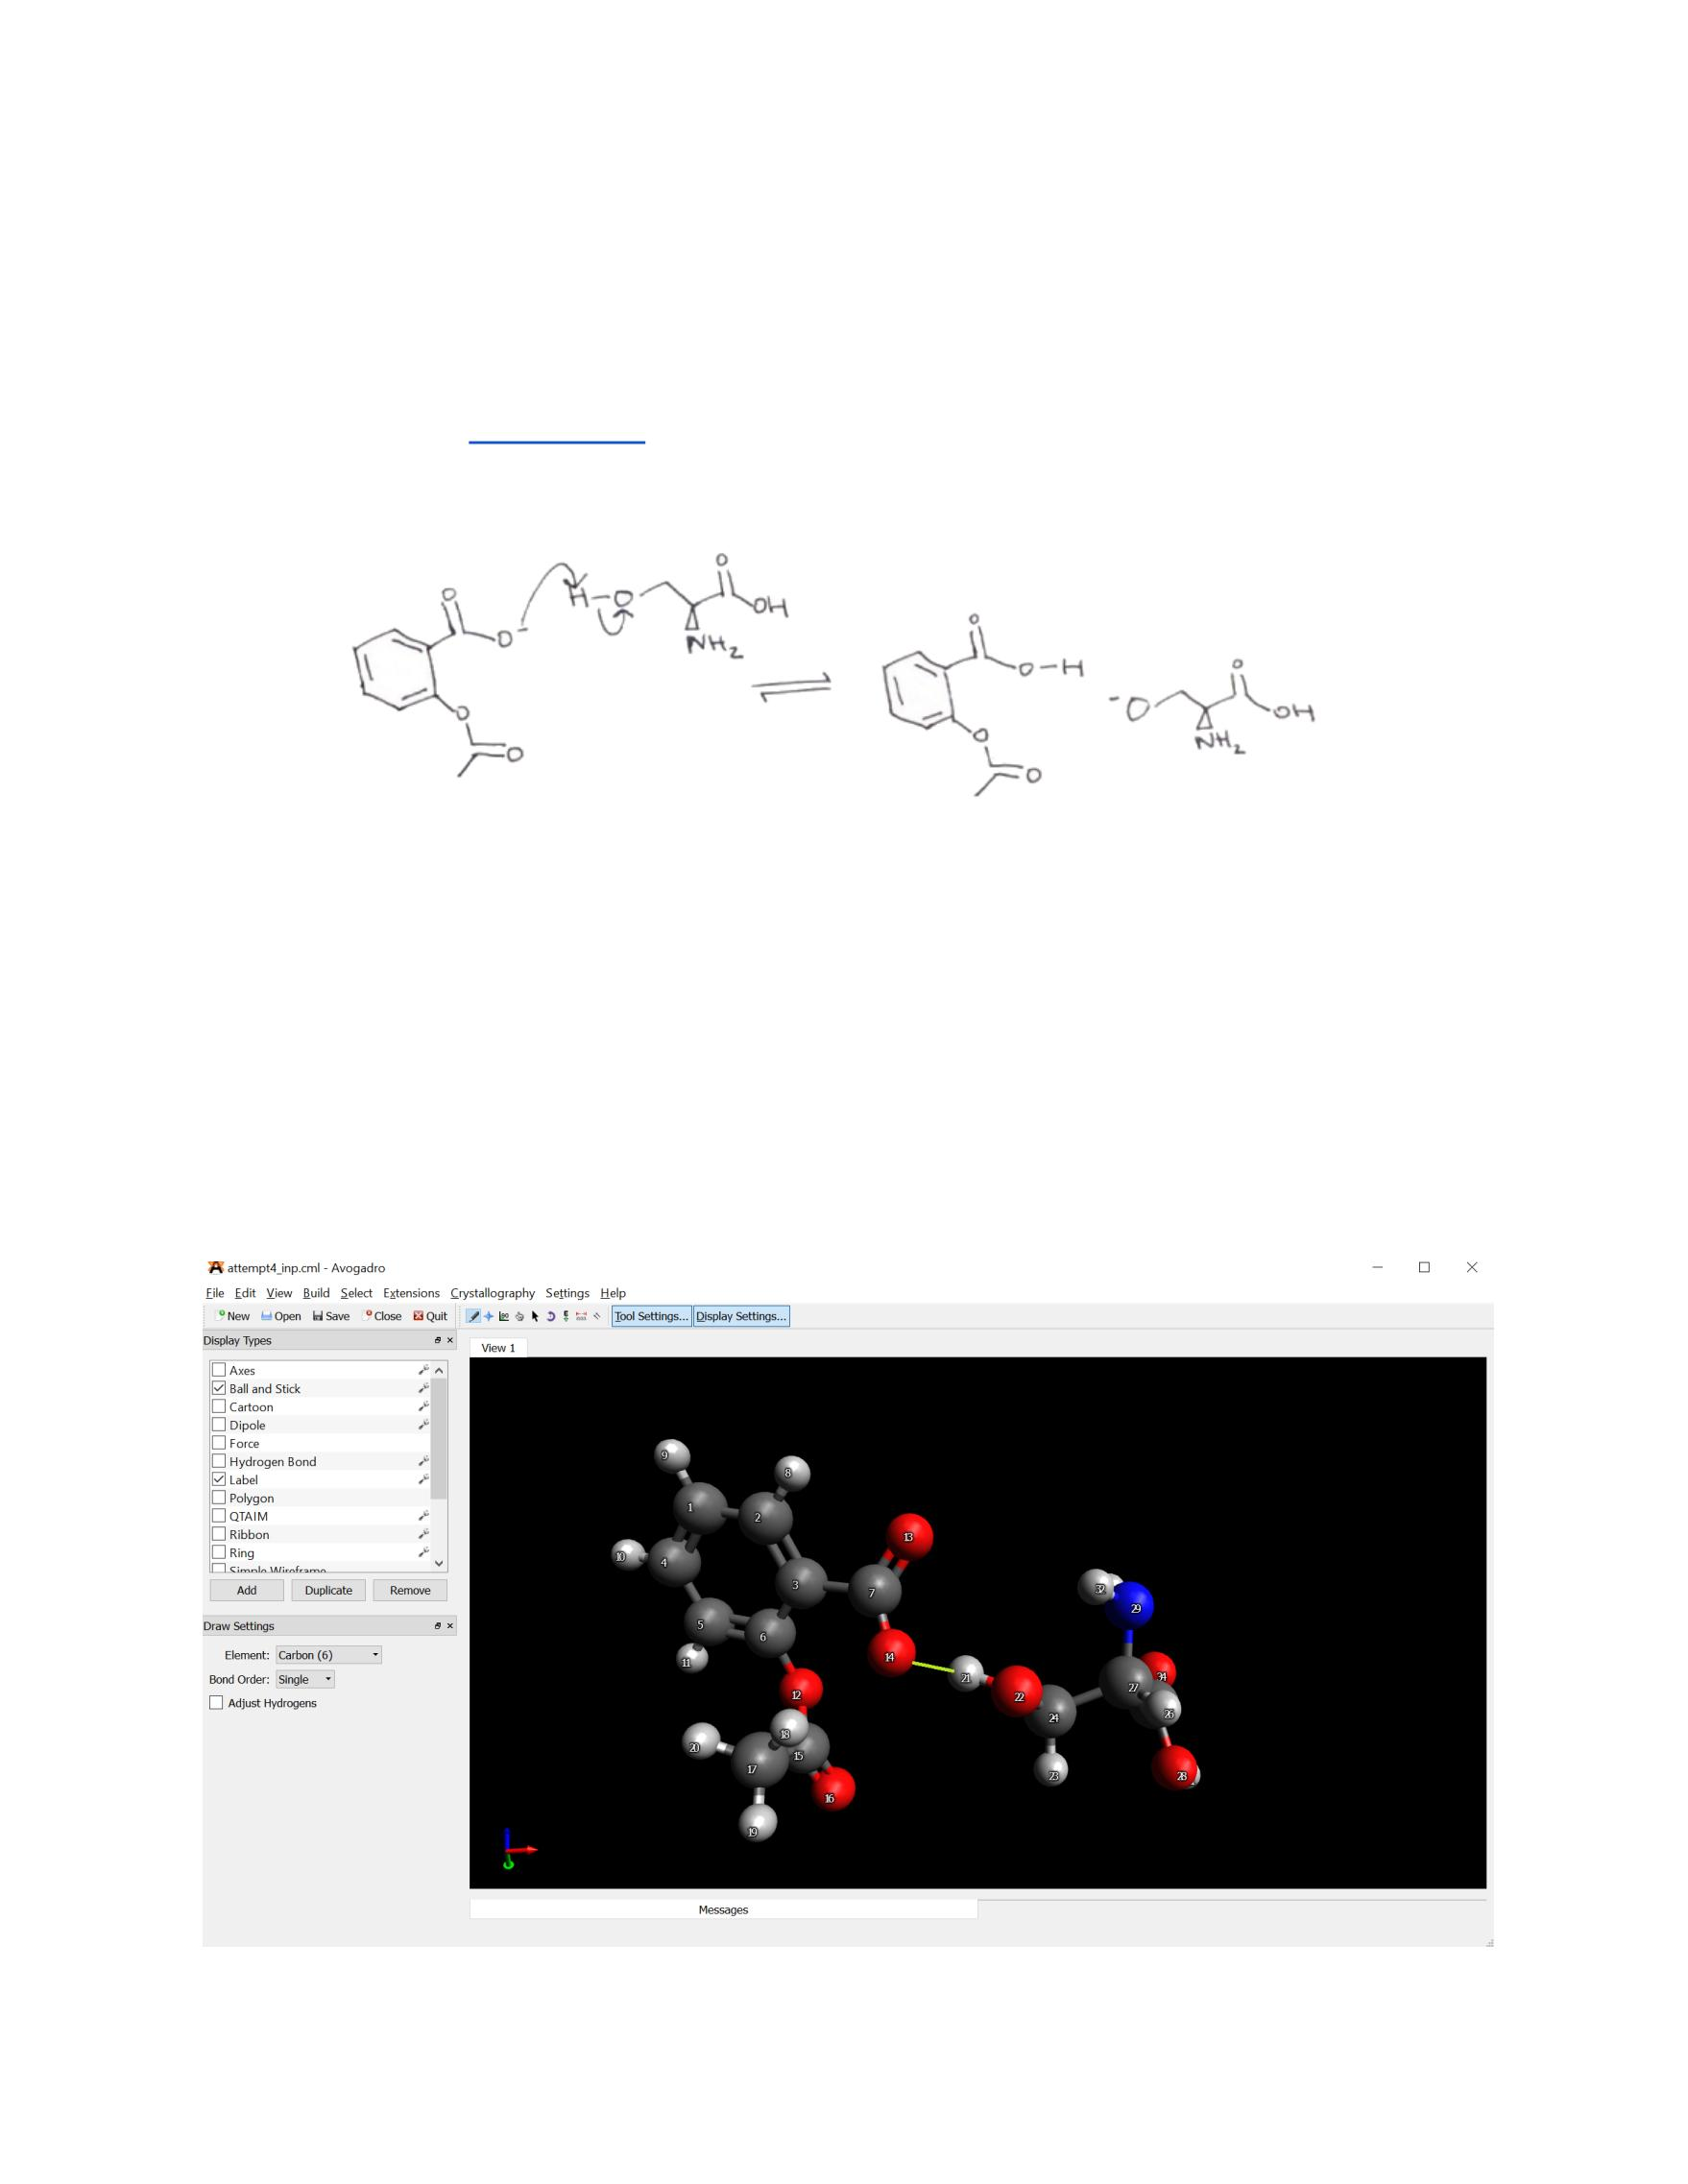

Avogadro (imagen arriba) y GaussView (imagen siguiente) son excelentes herramientas para la generación de inputs para estudiar los mecanismos de reacción

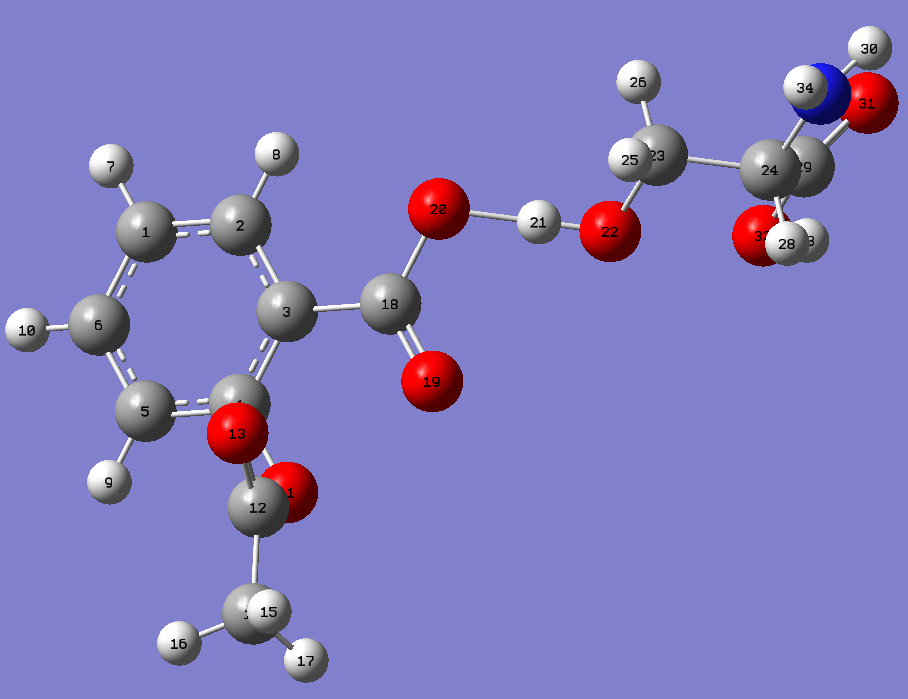

## 3.1 Script de partida

In [ ]:
import math

archivo = "complejo.xyz"

# índices (numeración química)
O_acceptor = 20
H = 21
O_donor = 22

atoms = []
coords = []

# ======================
# Leer archivo xyz
# ======================

with open(archivo) as f:
    lines = f.readlines()

n_atoms = int(lines[0])

for line in lines[2:2+n_atoms]:
    p = line.split()
    atoms.append(p[0])
    coords.append([float(p[1]), float(p[2]), float(p[3])])

# ======================
# coordenadas clave
# ======================

Oa = coords[O_acceptor-1]
Hd = coords[H-1]
Od = coords[O_donor-1]

# ======================
# vector O_acceptor -> O_donor
# ======================

vx = Od[0] - Oa[0]
vy = Od[1] - Oa[1]
vz = Od[2] - Oa[2]

norm = math.sqrt(vx*vx + vy*vy + vz*vz)

vx /= norm
vy /= norm
vz /= norm

# ======================
# nueva posición del H
# ======================

OH_dist = 0.98

newH = [
    Oa[0] + vx * OH_dist,
    Oa[1] + vy * OH_dist,
    Oa[2] + vz * OH_dist
]

coords[H-1] = newH

# ======================
# escribir producto.xyz
# ======================

with open("producto.xyz","w") as f:

    f.write(f"{n_atoms}\n")
    f.write("producto aproximado proton transfer\n")

    for atom,(x,y,z) in zip(atoms,coords):
        f.write(f"{atom} {x:.6f} {y:.6f} {z:.6f}\n")

print("producto.xyz generado correctamente")

## 3.2 Comando de ejecución

In [ ]:
!xtb complejo.xyz --path producto.xyz --gfn2 --chrg -1 --uhf 0

demoró 4 min

## 3.3 Leer energías desde xtbpath.xyz

In [ ]:
energies = []

with open("xtbpath.xyz") as f:
    lines = f.readlines()

for line in lines:
    if "energy" in line.lower():
        parts = line.split()
        e = float(parts[1])
        energies.append(e)

energies = np.array(energies)

# convertir a kcal/mol relativas
energies = (energies - energies.min()) * 627.509
energies

In [ ]:
#energies = np.delete(energies, 0)
#energies

## 3.4 Encontrar TS

In [ ]:
ts_index = np.argmax(energies)

print("Número de imágenes:", len(energies))
print("TS aproximado en imagen:", ts_index)
print("Energía de barrera (kcal/mol):", energies[ts_index])

## 3.5 Graficar perfil de energía

In [ ]:
plt.figure()

plt.plot(range(len(energies)), energies/1000, marker="o")

plt.xlabel("Imagen de reacción")
plt.ylabel("Energía relativa (kcal/mol)")
plt.title("Perfil de energía HCN → HNC (xTB-NEB)")

plt.scatter(ts_index, energies[ts_index]/1000, s=100, marker="*")

plt.show()